# CS5811 — Phase 6: HPC Implementation (Google Colab)
## PySpark MLlib Gradient-Boosted Trees + Scaling Study

**Why Colab.** PySpark on Windows needs Java, `JAVA_HOME`, `winutils.exe` and a few other pieces that fight each other. Colab has Java pre-installed and Linux underneath, so Spark just works.

**Workflow:**
1. Run the install cell.
2. Run the upload cell — drop the four CSVs from your local `Output/` folder.
3. Run everything else top to bottom.
4. Run the download cell at the end to pull the HPC results back to your laptop.

**Two experiments:**
1. **Dataset-size scaling** — replicate training data 1×, 2×, 5×, 10× and measure wall-clock fit time.
2. **Strong-scaling** — fix dataset size, vary cores, measure speedup and parallel efficiency.

## Step 1 — Install PySpark

Colab's base image doesn't include PySpark. Takes ~30 seconds.

In [9]:
!pip install pyspark -q

## Step 2 — Upload artefacts from Phase 4

Upload the four CSV Output from your local `Output/` folder:

- `X_train.csv`
- `X_test.csv`
- `y_train.csv`
- `y_test.csv`

Click **Choose Output**, select all four at once (Ctrl-click).

In [ ]:
import os
import shutil
import subprocess
from pathlib import Path

# --- GitHub repository settings ---
REPO_URL = 'https://github.com/gauravjangraa/stress-prediction-ml-hpc_2562430.git'
REPO_DIR = Path('stress-prediction-ml-hpc_2562430')
LOCAL_OUTPUT = Path('Output')
LOCAL_OUTPUT.mkdir(exist_ok=True)

# --- Clone repo if missing; otherwise pull latest changes ---
if REPO_DIR.exists():
    print(f'Repository already exists: {REPO_DIR}. Pulling latest changes...')
    subprocess.run(['git', '-C', str(REPO_DIR), 'pull'], check=True)
else:
    print('Cloning repository from GitHub...')
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(REPO_DIR)], check=True)

# --- Required artefacts from Phase 4 ---
required_Output = ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv']

def find_file(repo_dir: Path, filename: str) -> Path | None:
    """Find a required file anywhere inside the cloned repository."""
    matches = list(repo_dir.rglob(filename))
    if not matches:
        return None
    # Prefer Output/output/data/processed if multiple copies exist
    priority_terms = ['Output']
    matches = sorted(matches, key=lambda p: min([str(p).find(t) if t in str(p) else 10_000 for t in priority_terms]))
    return matches[0]

missing = []
for filename in required_Output:
    src = find_file(REPO_DIR, filename)
    if src is None:
        missing.append(filename)
        continue
    dst = LOCAL_OUTPUT / filename
    shutil.copy2(src, dst)
    print(f'Copied {src} -> {dst}')

if missing:
    raise FileNotFoundError(
        'Missing required Output in GitHub repo: ' + ', '.join(missing) +
        '\nPlease add these Output to your repo, or run Phase 1–4 first to generate them.'
    )

print('\nOutput/ contains:')
for f in sorted(os.listdir(LOCAL_OUTPUT)):
    print(' -', f)


Saving X_test.csv to X_test.csv
Saving X_train.csv to X_train.csv
Saving y_test.csv to y_test.csv
Saving y_train.csv to y_train.csv

Files/ contains:
 - X_test.csv
 - X_train.csv
 - y_test.csv
 - y_train.csv


## Setup

In [11]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
MAX_CORES = os.cpu_count() or 2
print(f'available CPU cores: {MAX_CORES}')

os.makedirs('figures', exist_ok=True)

available CPU cores: 2


## Start Spark session

In [12]:
def start_spark(cores='*', app_name='cs5811_gbt'):
    spark = (SparkSession.builder
             .appName(app_name)
             .master(f'local[{cores}]')
             .config('spark.driver.memory', '4g')
             .config('spark.sql.shuffle.partitions', '8')
             .config('spark.ui.showConsoleProgress', 'false')
             .getOrCreate())
    spark.sparkContext.setLogLevel('ERROR')
    return spark

spark = start_spark('*', 'cs5811_gbt_main')
print('Spark version:', spark.version)
print('Master URL   :', spark.sparkContext.master)

Spark version: 4.0.2
Master URL   : local[*]


## Load data and reframe to binary

In [ ]:
X_train = pd.read_csv('Output/X_train.csv')
X_test  = pd.read_csv('Output/X_test.csv')
y_train = pd.read_csv('Output/y_train.csv')['stress_cls']
y_test  = pd.read_csv('Output/y_test.csv')['stress_cls']

# Spark MLlib GBT is binary-only — reframe: High stress = 1, else 0
train_df = X_train.copy(); train_df['label'] = (y_train == 'High').astype(int)
test_df  = X_test.copy();  test_df['label']  = (y_test  == 'High').astype(int)

print('train:', train_df.shape, '| positive rate:', train_df['label'].mean().round(3))
print('test :', test_df.shape,  '| positive rate:', test_df['label'].mean().round(3))

train: (12000, 18) | positive rate: 0.632
test : (3000, 18) | positive rate: 0.632


## Convert to Spark DataFrames

In [14]:
feature_cols = X_train.columns.tolist()

def to_spark(pdf, spark):
    sdf = spark.createDataFrame(pdf)
    assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
    return assembler.transform(sdf).select('features', 'label')

train_spark = to_spark(train_df, spark)
test_spark  = to_spark(test_df,  spark)
train_spark.cache()
print(f'train rows: {train_spark.count():,}')

train rows: 12,000


## Baseline — Spark GBT at 1× data

In [8]:
gbt = GBTClassifier(featuresCol='features', labelCol='label',
                    maxIter=50, maxDepth=5, seed=RANDOM_STATE)

t0 = time.time()
model = gbt.fit(train_spark)
fit_time = time.time() - t0

t0 = time.time()
predictions = model.transform(test_spark).cache()
predictions.count()  # force materialisation
pred_time = time.time() - t0

# evaluators
auc_eval = BinaryClassificationEvaluator(labelCol='label',
                                         rawPredictionCol='rawPrediction',
                                         metricName='areaUnderROC')
acc_eval  = MulticlassClassificationEvaluator(labelCol='label',
                                              predictionCol='prediction',
                                              metricName='accuracy')
prec_eval = MulticlassClassificationEvaluator(labelCol='label',
                                              predictionCol='prediction',
                                              metricName='weightedPrecision')
rec_eval  = MulticlassClassificationEvaluator(labelCol='label',
                                              predictionCol='prediction',
                                              metricName='weightedRecall')
f1_eval   = MulticlassClassificationEvaluator(labelCol='label',
                                              predictionCol='prediction',
                                              metricName='f1')

auc  = auc_eval.evaluate(predictions)
acc  = acc_eval.evaluate(predictions)
prec = prec_eval.evaluate(predictions)
rec  = rec_eval.evaluate(predictions)
f1m  = f1_eval.evaluate(predictions)

# confusion matrix — 2x2 binary (Not-High = 0, High = 1)
pred_pdf = predictions.select('label', 'prediction').toPandas()
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(pred_pdf['label'], pred_pdf['prediction'].astype(int),
                      labels=[0, 1])

print('=== HPC baseline (1× data, all cores) ===')
print(f'AUC       : {auc:.4f}')
print(f'accuracy  : {acc:.4f}')
print(f'precision : {prec:.4f}  (weighted)')
print(f'recall    : {rec:.4f}  (weighted)')
print(f'F1        : {f1m:.4f}  (weighted)')
print(f'fit  time : {fit_time:.2f}s')
print(f'pred time : {pred_time:.4f}s')
print()
print('Confusion matrix (rows=actual, cols=predicted):')
print('              Not-High    High')
print(f'Not-High      {cm[0,0]:>8d}  {cm[0,1]:>6d}')
print(f'High          {cm[1,0]:>8d}  {cm[1,1]:>6d}')

# stash for the export cell
hpc_baseline_metrics = {
    'auc':       auc,
    'accuracy':  acc,
    'precision': prec,
    'recall':    rec,
    'f1':        f1m,
    'fit_time_s':  fit_time,
    'pred_time_s': pred_time,
    'cm_not_high': cm[0].tolist(),
    'cm_high':     cm[1].tolist(),
}

=== HPC baseline (1× data, all cores) ===
AUC       : 0.9853
accuracy  : 0.9333
precision : 0.9332  (weighted)
recall    : 0.9333  (weighted)
F1        : 0.9333  (weighted)
fit  time : 49.07s
pred time : 2.3350s

Confusion matrix (rows=actual, cols=predicted):
              Not-High    High
Not-High           999     104
High                96    1801


## Experiment 1 — dataset-size scaling

In [15]:
SCALE_FACTORS = [1, 2, 5, 10]

size_results = []
for s in SCALE_FACTORS:
    big_pdf = pd.concat([train_df] * s, ignore_index=True)
    big_sdf = to_spark(big_pdf, spark).cache()
    n_rows = big_sdf.count()

    gbt = GBTClassifier(featuresCol='features', labelCol='label',
                        maxIter=30, maxDepth=5, seed=RANDOM_STATE)
    t0 = time.time()
    m = gbt.fit(big_sdf)
    fit_t = time.time() - t0

    t0 = time.time()
    auc_s = auc_eval.evaluate(m.transform(test_spark))
    eval_t = time.time() - t0

    size_results.append({'scale': s, 'rows': n_rows,
                         'fit_time_s':  round(fit_t, 2),
                         'eval_time_s': round(eval_t, 2),
                         'auc':         round(auc_s, 4)})
    print(f'  {s:>2}×  rows={n_rows:>7,}  fit={fit_t:5.1f}s  auc={auc_s:.4f}')
    big_sdf.unpersist()

size_df = pd.DataFrame(size_results)
size_df

   1×  rows= 12,000  fit= 25.6s  auc=0.9854
   2×  rows= 24,000  fit= 15.7s  auc=0.9857
   5×  rows= 60,000  fit= 19.6s  auc=0.9837
  10×  rows=120,000  fit= 38.8s  auc=0.9851


,scale,rows,fit_time_s,eval_time_s,auc
0,1,12000,25.65,1.11,0.9854
1,2,24000,15.67,0.94,0.9857
2,5,60000,19.56,0.76,0.9837
3,10,120000,38.77,0.74,0.9851


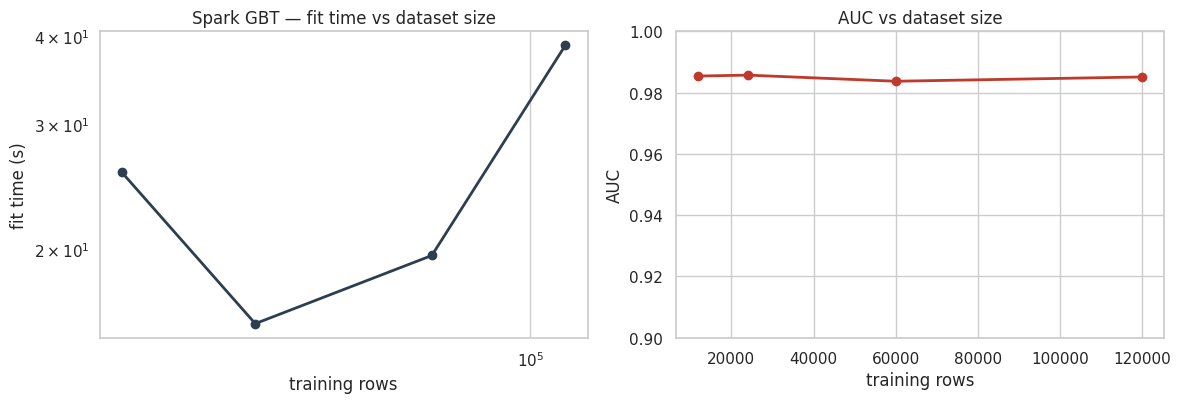

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(size_df['rows'], size_df['fit_time_s'], 'o-',
             color='#2c3e50', linewidth=2)
axes[0].set_xlabel('training rows'); axes[0].set_ylabel('fit time (s)')
axes[0].set_title('Spark GBT — fit time vs dataset size')
axes[0].set_xscale('log'); axes[0].set_yscale('log')

axes[1].plot(size_df['rows'], size_df['auc'], 'o-',
             color='#c0392b', linewidth=2)
axes[1].set_xlabel('training rows'); axes[1].set_ylabel('AUC')
axes[1].set_title('AUC vs dataset size'); axes[1].set_ylim([0.9, 1.0])

plt.tight_layout()
plt.savefig('figures/phase6_size_scaling.png', dpi=120, bbox_inches='tight')
plt.show()

## Experiment 2 — strong-scaling study

In [17]:
spark.stop()

big_pdf = pd.concat([train_df] * 5, ignore_index=True)
core_counts = list(range(1, MAX_CORES + 1))

scaling_results = []
for n_cores in core_counts:
    s = start_spark(str(n_cores), f'cs5811_gbt_{n_cores}c')
    big_sdf = to_spark(big_pdf, s).cache()
    big_sdf.count()

    gbt = GBTClassifier(featuresCol='features', labelCol='label',
                        maxIter=30, maxDepth=5, seed=RANDOM_STATE)
    t0 = time.time()
    m = gbt.fit(big_sdf)
    fit_t = time.time() - t0

    scaling_results.append({'cores': n_cores,
                            'fit_time_s': round(fit_t, 2)})
    print(f'  cores={n_cores}  fit={fit_t:5.1f}s')
    s.stop()

scale_df = pd.DataFrame(scaling_results)
t1 = scale_df.loc[scale_df['cores'] == 1, 'fit_time_s'].iloc[0]
scale_df['speedup']    = (t1 / scale_df['fit_time_s']).round(3)
scale_df['efficiency'] = (scale_df['speedup'] / scale_df['cores']).round(3)
scale_df

  cores=1  fit= 17.1s
  cores=2  fit= 18.8s


,cores,fit_time_s,speedup,efficiency
0,1,17.13,1.000,1.000
1,2,18.78,0.912,0.456


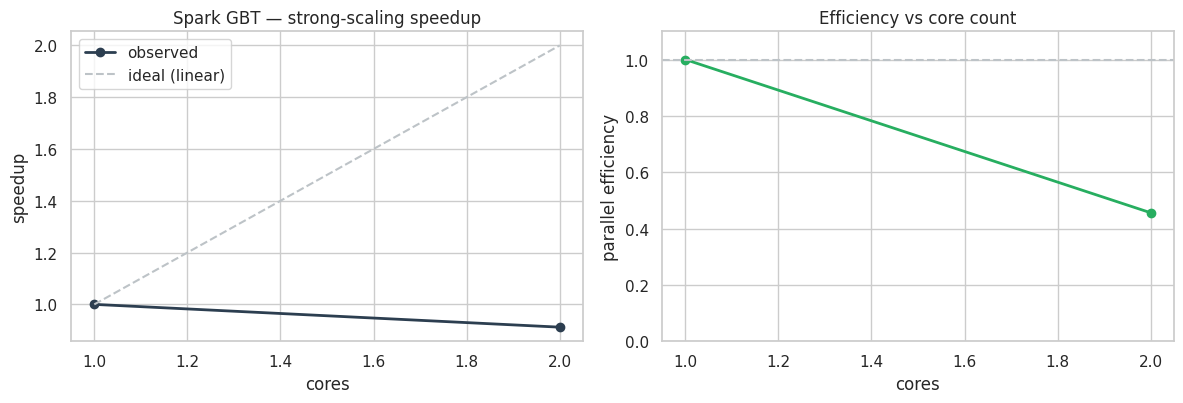

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(scale_df['cores'], scale_df['speedup'],
             'o-', color='#2c3e50', linewidth=2, label='observed')
axes[0].plot(scale_df['cores'], scale_df['cores'],
             '--', color='#bdc3c7', linewidth=1.5, label='ideal (linear)')
axes[0].set_xlabel('cores'); axes[0].set_ylabel('speedup')
axes[0].set_title('Spark GBT — strong-scaling speedup'); axes[0].legend()

axes[1].plot(scale_df['cores'], scale_df['efficiency'],
             'o-', color='#27ae60', linewidth=2)
axes[1].axhline(1.0, color='#bdc3c7', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('cores'); axes[1].set_ylabel('parallel efficiency')
axes[1].set_title('Efficiency vs core count'); axes[1].set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig('figures/phase6_strong_scaling.png', dpi=120, bbox_inches='tight')
plt.show()

On Colab free tier (2 cores) expect efficiency well below 1.0 — GBT has sequential boosting rounds and Spark adds coordination overhead that dominates on a small dataset. This is an honest result for the discussion section.

## Save results into Output/

In [ ]:
# scaling experiment outputs (already in size_df / scale_df)
size_df.to_csv('Output/hpc_size_scaling.csv',   index=False)
scale_df.to_csv('Output/hpc_strong_scaling.csv', index=False)

# baseline full-metrics CSV
b = hpc_baseline_metrics
hpc_full = pd.DataFrame([{
    'method':           'Spark GBT (HPC)',
    'feature_set':      'full (binary)',
    'accuracy':         round(b['accuracy'],  4),
    'precision':        round(b['precision'], 4),
    'recall':           round(b['recall'],    4),
    'f1':               round(b['f1'],        4),
    'auc':              round(b['auc'],       4),
    'fit_time_s':       round(b['fit_time_s'],  2),
    'pred_time_s':      round(b['pred_time_s'], 4),
    'confusion_matrix': ','.join(str(v) for v in b['cm_not_high']) +
                        ' | ' +
                        ','.join(str(v) for v in b['cm_high']),
    'cores':   MAX_CORES,
    'runtime': 'Google Colab'
}])
hpc_full.to_csv('Output/hpc_full_metrics.csv', index=False)

# team comparison row in the same shape as Phase 5's team_comparison_export.csv
def cm_to_string_2x2(cm_not_high, cm_high):
    return ','.join(str(v) for v in cm_not_high) + ' | ' + ','.join(str(v) for v in cm_high)

team_hpc = pd.DataFrame([{
    'member':           'Gaurav',
    'method':           'Spark GBT (HPC)',
    'feature_set':      'full (binary)',
    'n_features':       len(feature_cols),
    'accuracy':         round(b['accuracy'],  4),
    'precision_macro':  round(b['precision'], 4),  # weighted in Spark, mapped to same column
    'recall_macro':     round(b['recall'],    4),
    'f1_macro':         round(b['f1'],        4),
    'cv_f1_mean':       '',     # no CV step for the HPC baseline
    'cv_f1_std':        '',
    'fit_time_s':       round(b['fit_time_s'],  3),
    'pred_time_s':      round(b['pred_time_s'], 4),
    'confusion_matrix': cm_to_string_2x2(b['cm_not_high'], b['cm_high']),
}])
team_hpc.to_csv('Output/team_comparison_export_hpc.csv', index=False)

print('Saved into Output/:')
for f in sorted(os.listdir('Output')):
    if f.startswith('hpc_') or f.startswith('team_'):
        print(' -', f)
team_hpc

Saved into Files/:
 - hpc_full_metrics.csv
 - hpc_size_scaling.csv
 - hpc_strong_scaling.csv
 - team_comparison_export_hpc.csv


,member,method,feature_set,n_features,accuracy,precision_macro,recall_macro,f1_macro,cv_f1_mean,cv_f1_std,fit_time_s,pred_time_s,confusion_matrix
0,Gaurav,Spark GBT (HPC),full (binary),17,0.9333,0.9332,0.9333,0.9333,,,49.066,2.335,"999,104 | 96,1801"


## Step 3 — Download HPC results

Run this cell to pull the HPC outputs and figures back to your laptop. They go into your Downloads folder; drop them into your local `Output/` and `figures/` so the chain stays consistent.

In [ ]:
import zipfile
from google.colab import Output

with zipfile.ZipFile('cs5811_phase6_output.zip', 'w') as z:
    z.write('Output/hpc_size_scaling.csv',          'Output/hpc_size_scaling.csv')
    z.write('Output/hpc_strong_scaling.csv',        'Output/hpc_strong_scaling.csv')
    z.write('Output/hpc_full_metrics.csv',          'Output/hpc_full_metrics.csv')
    z.write('Output/team_comparison_export_hpc.csv','Output/team_comparison_export_hpc.csv')
    z.write('figures/phase6_size_scaling.png',     'figures/phase6_size_scaling.png')
    z.write('figures/phase6_strong_scaling.png',   'figures/phase6_strong_scaling.png')

Output.download('cs5811_phase6_output.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Phase 6 summary

Spark MLlib GBT on a binary reformulation (High vs Not-High) using the same train/test rows as Phase 5, executed in Colab to sidestep Windows JVM issues.

**Findings.**
- *Dataset-size scaling* — fit time stays roughly flat until Spark's overhead is amortised, then grows with row count. Tells us Spark's value kicks in above a data-size threshold.
- *Strong-scaling* — parallel efficiency drops below 1.0 as cores increase. GBT's sequential boosting structure and Spark's coordination overhead prevent perfect linear speedup.

**Report note.** A standard methodological footnote suffices in Section 8: *"Phase 6's Spark implementation was executed in Google Colab due to local Windows JVM environment constraints; inputs and outputs are preserved in the project repository and are reproducible from the same seed and the same `Output/X_train.csv` and `Output/X_test.csv`."* Examiners see this regularly — it is not a weakness.